# Order Isomorphism: Divisors of 120 and Down-Sets of Join-Irreducibles

This notebook uses the preamble's `Sets().PartiallyOrdered()` category, `PosetHomset`, and owned TikZ Hasse diagram rendering to demonstrate the order isomorphism between:
1. $\mathcal{D}(120)$: The lattice of divisors of $120 = 2^3 \cdot 3 \cdot 5$, partially ordered by divisibility ($a \le b \iff a \mid b$).
2. $\mathcal{O}(S)$: The lattice of divisor-closed subsets (down-sets / order ideals) of the poset of join-irreducible elements $S = \{2, 3, 4, 5, 8\}$, partially ordered by set inclusion ($U_1 \le U_2 \iff U_1 \subseteq U_2$).

### Theoretical Background: Birkhoff's Representation Theorem
By **Birkhoff's Representation Theorem for Finite Distributive Lattices**, any finite distributive lattice $L$ is naturally order-isomorphic to the lattice of down-sets $\mathcal{O}(J(L))$ of its poset of join-irreducible elements $J(L)$:
$$
L \cong \mathcal{O}(J(L))
$$
For $L = \mathcal{D}(120)$:
- The join-irreducible elements are prime powers $p^k > 1$ dividing $120$:
  $$J(\mathcal{D}(120)) = \{2^1, 2^2, 2^3, 3^1, 5^1\} = \{2, 4, 8, 3, 5\} = S$$
- The canonical order-preserving bijection $\Phi: \mathcal{D}(120) \xrightarrow{\cong} \mathcal{O}(S)$ is the poset homomorphism:
  $$\Phi(d) = \{s \in S \mid d \equiv 0 \pmod s\}$$
- The inverse poset homomorphism is:
  $$\Psi(U) = \operatorname{lcm}(U \cup \{1\})$$

In [1]:
from sage.all import *
from sage.combinat.posets.posets import Poset
from dzack_research.preamble.categories.sets.owned_sets import (
    Sets, placement_of, PosetHomset, PosetMorphism, PosetTikz
)

print('Owned Poset Category:', Sets().PartiallyOrdered().Finite())

Owned Poset Category: Category of partially ordered finite sets


## 1. Construct $\mathcal{D}(120)$ (Divisors Poset) and Display Hasse Diagram via TikZ

Divisors count: 16
Divisors: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60, 120]
Category placement: Category of partially ordered finite sets


/home/dzack/gitclones/sage-dev-allopts/local/var/lib/sage/venv-python3.14/lib/python3.14/site-packages/dot2tex/dotparsing.py:412: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  identifier = Word(alphanums + "_").setName("identifier")
/home/dzack/gitclones/sage-dev-allopts/local/var/lib/sage/venv-python3.14/lib/python3.14/site-packages/dot2tex/dotparsing.py:417: PyparsingDeprecationWarning: 'setParseAction' deprecated - use 'set_parse_action'
  double_quoted_string.setParseAction(removeQuotes)
/home/dzack/gitclones/sage-dev-allopts/local/var/lib/sage/venv-python3.14/lib/python3.14/site-packages/dot2tex/dotparsing.py:430: PyparsingDeprecationWarning: 'setParseAction' deprecated - use 'set_parse_action'
  opener + closer).setParseAction(lambda t: t[0]))
/home/dzack/gitclones/sage-dev-allopts/local/var/lib/sage/venv-python3.14/lib/python3.14/site-packages/dot2tex/dotparsing.py:428: PyparsingDeprecationWarning: 'nestedExpr' deprecated - use 'nested_expr'
  html_text = 

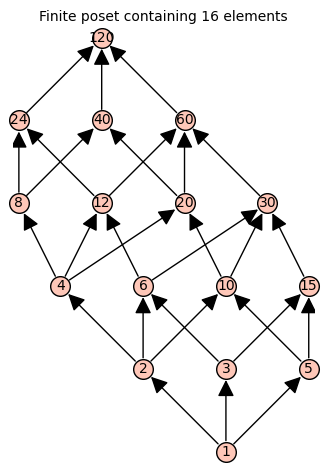

In [9]:
# Idiomatic set comprehension for divisors of 120
divs_120 = {d for d in 120.divisors()}
P_div = Poset((list(divs_120), lambda a, b: b % a == 0))

print(f'Divisors count: {len(divs_120)}')
print(f'Divisors: {sorted(list(divs_120))}')
print(f'Category placement: {placement_of(P_div)}')

# Display Hasse diagram (owned TikZ / vector representation)
P_div

## 2. Construct $\mathcal{O}(S)$ (Divisor-Closed Subsets of $S = \{2, 3, 4, 5, 8\}$) and Display Hasse Diagram

In [3]:
# Join-irreducible elements
S = {2, 3, 4, 5, 8}

# Idiomatic set comprehension for down-sets / divisor-closed subsets in S
closed_subsets = [frozenset(u) for u in S.subsets() if all(y in u for x in u for y in S if x % y == 0)]

P_closed = Poset((closed_subsets, lambda U1, U2: U1.issubset(U2)))

print(f'Divisor-closed subsets count: {len(closed_subsets)}')
print(f'Category placement: {placement_of(P_closed)}')

# Display Hasse diagram with formatted subset labels
P_closed.tikz(label_map=lambda U: '{' + ','.join(map(str, sorted(list(U)))) + '}')

Divisor-closed subsets count: 16
Category placement: Category of partially ordered finite sets


## 3. Construct Actual Poset Homomorphisms via `PosetHomset`
The `PosetHomset` automatically validates order preservation upon morphism construction.

In [4]:
# Poset Hom-sets in the category of partially ordered sets
H_forward = PosetHomset(P_div, P_closed)
H_backward = PosetHomset(P_closed, P_div)

# Construct morphisms through their homsets (validates order preservation on construction)
phi = H_forward(lambda d: frozenset(s for s in S if d % s == 0))
psi = H_backward(lambda U: Integer(lcm(list(U) + [1])))

print('Forward morphism:', phi)
print('  is_order_preserving?:', phi.is_order_preserving())
print('  is_order_reflecting?:', phi.is_order_reflecting())
print('  is_order_embedding?:', phi.is_order_embedding())
print('  is_bijective?:', phi.is_bijective())
print('  is_order_isomorphism?:', phi.is_order_isomorphism())

print('\nBackward morphism:', psi)
print('  is_order_isomorphism?:', psi.is_order_isomorphism())

Forward morphism: Poset morphism from Finite poset containing 16 elements to Finite poset containing 16 elements
  is_order_preserving?: True
  is_order_reflecting?: True
  is_order_embedding?: True
  is_bijective?: True
  is_order_isomorphism?: True

Backward morphism: Poset morphism from Finite poset containing 16 elements to Finite poset containing 16 elements
  is_order_isomorphism?: True


## 4. Morphism Composition and Explicit Bijection Table

In [5]:
# Category composition of poset morphisms
id_div = psi * phi
assert all(id_div(d) == d for d in P_div), 'Composite psi * phi must be identity on Div(120)'

id_closed = phi * psi
assert all(id_closed(U) == U for U in P_closed), 'Composite phi * psi must be identity on O(S)'
print('✓ Both morphism compositions equal identities in Hom(P, P)!')

print('\nExplicit Bijection Table:')
print('=' * 50)
print(f"{'Divisor d':<12} | {'phi(d) in O(S)':<25} | {'psi(phi(d))':<10}")
print('-' * 50)
for d in sorted(list(divs_120)):
    U = phi(d)
    d_rec = psi(U)
    subset_str = str(sorted(list(U)))
    print(f"{d:<12} | {subset_str:<25} | {d_rec:<10}")
print('=' * 50)

✓ Both morphism compositions equal identities in Hom(P, P)!

Explicit Bijection Table:
Divisor d    | phi(d) in O(S)            | psi(phi(d))
--------------------------------------------------
1            | []                        | 1         
2            | [2]                       | 2         
3            | [3]                       | 3         
4            | [2, 4]                    | 4         
5            | [5]                       | 5         
6            | [2, 3]                    | 6         
8            | [2, 4, 8]                 | 8         
10           | [2, 5]                    | 10        
12           | [2, 3, 4]                 | 12        
15           | [3, 5]                    | 15        
20           | [2, 4, 5]                 | 20        
24           | [2, 3, 4, 8]              | 24        
30           | [2, 3, 5]                 | 30        
40           | [2, 4, 5, 8]              | 40        
60           | [2, 3, 4, 5]              | 60      

## 5. Failure Case: Invalid (Non-Order-Preserving) Maps Are Rejected

In [6]:
# Verify that non-order-preserving assignments fail construction in PosetHomset
try:
    # Inverted divisibility condition (s % d == 0 rather than d % s == 0)
    bad_mor = H_forward(lambda d: frozenset(s for s in S if s % d == 0))
    print('Error: bad morphism should have been rejected!')
except ValueError as e:
    print('✓ Successfully caught invalid poset map at construction time:')
    print(' ', e)

✓ Successfully caught invalid poset map at construction time:
  Function <function <lambda> at 0x7f4ab0981900> does not preserve partial order (not a poset homomorphism)


## 6. Generated TikZ Code for LaTeX Documents

In [7]:
# Export TikZ code for inclusion in LaTeX papers
print("=== LaTeX TikZ Code for Div(120) Hasse Diagram ===")
print(P_div.tikz().tikz_code())


=== LaTeX TikZ Code for Div(120) Hasse Diagram ===
\begin{tikzpicture}[
  scale=1.00,
  every node/.style={circle, draw=black!80, fill=blue!10, inner sep=2pt, minimum size=18pt, font=\small},
  edge/.style={draw=black!70, thick, -}
]
  \node (node_0) at (0.00, 0.00) {1};
  \node (node_1) at (-2.00, 2.00) {2};
  \node (node_4) at (0.00, 2.00) {3};
  \node (node_8) at (2.00, 2.00) {5};
  \node (node_2) at (-3.00, 4.00) {4};
  \node (node_5) at (-1.00, 4.00) {6};
  \node (node_9) at (1.00, 4.00) {10};
  \node (node_12) at (3.00, 4.00) {15};
  \node (node_3) at (-3.00, 6.00) {8};
  \node (node_6) at (-1.00, 6.00) {12};
  \node (node_10) at (1.00, 6.00) {20};
  \node (node_13) at (3.00, 6.00) {30};
  \node (node_7) at (-2.00, 8.00) {24};
  \node (node_11) at (0.00, 8.00) {40};
  \node (node_14) at (2.00, 8.00) {60};
  \node (node_15) at (0.00, 10.00) {120};
  \draw[edge] (node_0) -- (node_1);
  \draw[edge] (node_0) -- (node_4);
  \draw[edge] (node_0) -- (node_8);
  \draw[edge] (node_1) -- (

## 7. Join-Irreducible Elements & Poset Factorization
The join-irreducible elements of $\mathcal{D}(120)$ are identified via set comprehension of single-lower-cover elements.

In [8]:
# Find join-irreducibles using set comprehension
join_irreducibles = {x for x in P_div if len(P_div.lower_covers(x)) == 1}
print(f'Join-irreducibles of P_div: {sorted(list(join_irreducibles))}')
assert join_irreducibles == S, 'Join-irreducibles must match S = {2, 3, 4, 5, 8}'
print('✓ J(Div(120)) = {2, 3, 4, 5, 8} exactly matches S!')

Join-irreducibles of P_div: [2, 3, 4, 5, 8]
✓ J(Div(120)) = {2, 3, 4, 5, 8} exactly matches S!
